In [6]:
# %pip install biopython matplotlib seaborn

### **Sequio Parse:  Reading FASTA files**

#### **Fasta File Format**

DNA and protein sequences are the most common data types in bio and standard file format for storing these sequences is FASTA.

**DNA:** A,T,G,C

**Protein:** letter acronyms as A: Alanine, T: Threonine, G: Glycine, C: Cysteine

A FASTA record begins with a one liner identifier line starting with > (greater than sign) and then the sequence lines follow, FASTA can contain more than one record.

**Example of FASTA format sequence:**

In [ ]:
>sequence_1
ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
>sequence_2
ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG

In [1]:
# getting the data
!rm -f SRR003265.filt.fastq.gz 2>/dev/null
!wget -nd ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/phase3/data/NA18489/sequence_read/SRR003265.filt.fastq.gz

The system cannot find the path specified.
--2026-02-20 20:28:11--  ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/phase3/data/NA18489/sequence_read/SRR003265.filt.fastq.gz
           => 'SRR003265.filt.fastq.gz'
Resolving ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)... 193.62.193.167
Connecting to ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)|193.62.193.167|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /vol1/ftp/phase3/data/NA18489/sequence_read ... done.
==> SIZE SRR003265.filt.fastq.gz ... 28919712
==> PASV ... done.    ==> RETR SRR003265.filt.fastq.gz ... done.
Length: 28919712 (28M) (unauthoritative)

     0K .......... .......... .......... .......... ..........  0% 56.5K 8m19s
    50K .......... .......... .......... .......... ..........  0%  197K 5m21s
   100K .......... .......... .......... .......... ..........  0% 12.8M 3m34s
   150K .......... .......... .......... .......... .

**Biopython SeqIO package**
provides interface for reading and writing sequence data

parse(file_path, format) - read in a sequence file as SeqRecord objects containing info as: 
- id: ID used to indentify the sequence (a string)
- seq: seq object containing the sequence (convert to string as: str())

In [ ]:
# reading the FASTQ files
# extracting one sequencing read, 
# and inspecting its sequence and quality scores using Biopython.
from collections import defaultdict
import gzip

%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

from Bio import SeqIO

recs = SeqIO.parse(gzip.open('SRR003265.filt.fastq.gz', 'rt', encoding='utf-8'), 'fastq')
rec = next(recs)
print(rec)
print(rec.id, rec.description, rec.seq)
print(rec.letter_annotations) # quality scores of our reads, per letter

ID: SRR003265.31
Name: SRR003265.31
Description: SRR003265.31 3042NAAXX:3:1:1252:1819 length=51
Number of features: 0
Per letter annotation for: phred_quality
Seq('GGGAAAAGAAAAACAAACAAACAAAAACAAAACACAGAAACAAAAAAACCA')
SRR003265.31 SRR003265.31 3042NAAXX:3:1:1252:1819 length=51 GGGAAAAGAAAAACAAACAAACAAAAACAAAACACAGAAACAAAAAAACCA
{'phred_quality': [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 30, 23, 40, 32, 35, 29, 40, 16, 40, 40, 32, 35, 31, 40, 40, 39, 22, 40, 24, 20, 28, 31, 12, 31, 10, 22, 28, 13, 26, 20, 23, 23]}


In [8]:
# Distribution of nucleotide reads

# computing the base composition of all sequencing reads in a FASTQ file, 
# it counts how many times each nucleotide (A, T, G, C, etc.) 
# appears and prints their percentage and total count.

recs = SeqIO.parse(gzip.open('SRR003265.filt.fastq.gz', 'rt', encoding='utf-8'), 'fastq')
count = defaultdict(int)
for rec in recs:
    for letter in rec.seq:
        count[letter] += 1
tot = sum(count.values())
for letter, count in count.items():
    print('%s: %.2f %d' % (letter, 100. * count / tot, count))

G: 20.68 5359334
A: 28.60 7411965
C: 21.00 5444053
T: 29.58 7666885
N: 0.14 37289


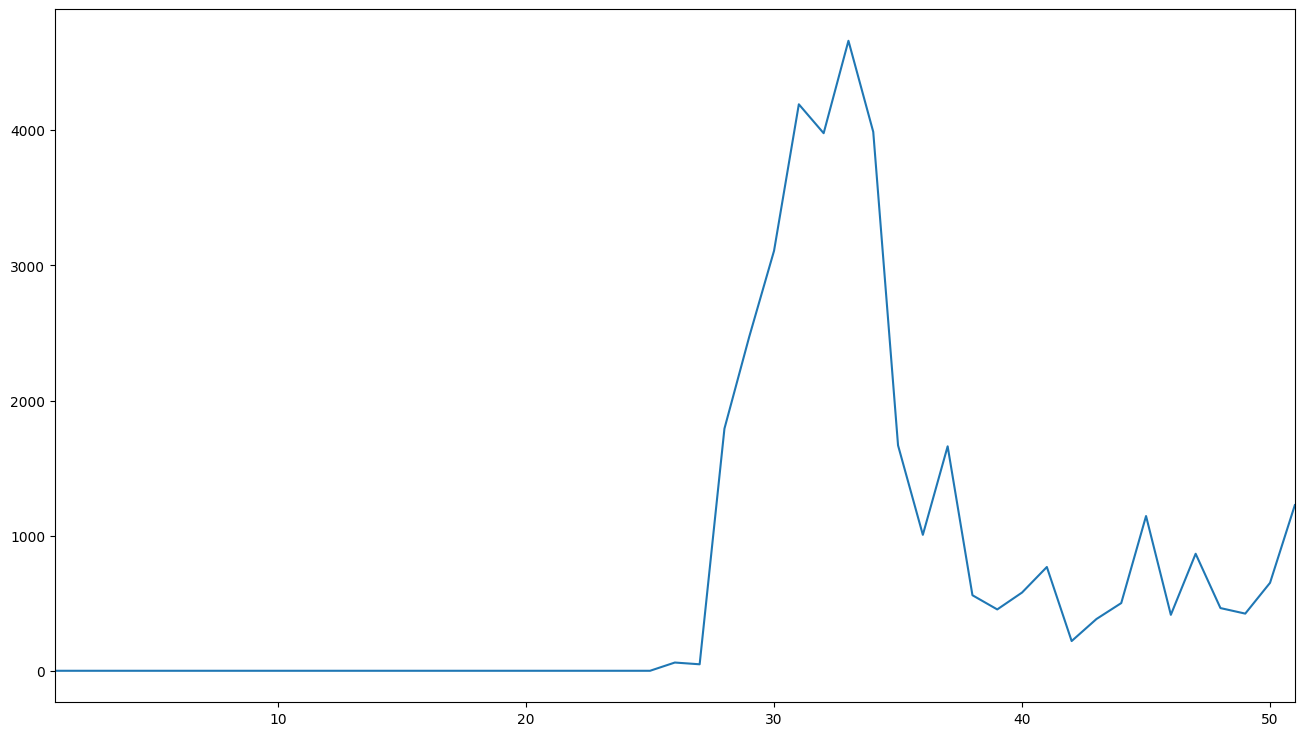

In [9]:
# position-wise frequency of ambiguous bases (N) in sequencing reads
# ATGC -> confident
#  N -> unknown base

recs = SeqIO.parse(gzip.open('SRR003265.filt.fastq.gz', 'rt', encoding='UTF-8'), 'fastq')
n_cnt = defaultdict(int)
for rec in recs:
    for i, letter in enumerate(rec.seq):
        pos = i + 1
        if letter == 'N':
            n_cnt[pos] += 1
seq_len = max(n_cnt.keys())
positions = range(1, seq_len + 1)
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(positions, [n_cnt[x] for x in positions])
ax.set_xlim(1, seq_len)
pass
